In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
# Import dataset and make a CustomerID column to index
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/telco_customer_churn (1).csv")

# Preview the first few rows
df.head()

,Customer ID,Gender,Senior Citizen,Partner,Dependents,tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,7590-VHVEA,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [ ]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Check for missing values
print(df.isnull().sum())

# 'TotalCharges' is numeric but may have spaces that cause issues — convert it:
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')

# This gets rid of rows where Total_Charges couldn’t be converted.
df = df.dropna()

# Drop 'customerID' column since it's just an identifier
df.drop('Customer_ID', axis=1, inplace=True)
print("COLUMNS : ",df.columns.tolist())
print("SHAPE : ",df.shape)

Customer_ID          0
Gender               0
Senior_Citizen       0
Partner              0
Dependents           0
tenure               0
Phone_Service        0
Multiple_Lines       0
Internet_Service     0
Online_Security      0
Online_Backup        0
Device_Protection    0
Tech_Support         0
Streaming_TV         0
Streaming_Movies     0
Contract             0
Paperless_Billing    0
Payment_Method       0
Monthly_Charges      0
Total_Charges        0
Churn                0
dtype: int64
COLUMNS :  ['Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'tenure', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn']
SHAPE :  (7033, 20)


/tmp/ipython-input-4094194793.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('Customer_ID', axis=1, inplace=True)


In [ ]:
print("Before : ")
display(df.head())

# Convert target column 'Churn' to binary (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Identify all remaining categorical columns (type 'object')
cat_cols = df.select_dtypes(include='object').columns

# Encode each categorical column into numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    display(df[col].unique())  # Display unique values before encoding
    df[col] = le.fit_transform(df[col])

print("After : ")
display(df.head())

Before : 


,Gender,Senior_Citizen,Partner,Dependents,tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


/tmp/ipython-input-1342223735.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


array(['Female', 'Male'], dtype=object)

/tmp/ipython-input-1342223735.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])


...

/tmp/ipython-input-1342223735.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])


array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

After : 


/tmp/ipython-input-1342223735.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])


,Gender,Senior_Citizen,Partner,Dependents,tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
2,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
3,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
4,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('Churn', axis=1)  # all columns except target
y = df['Churn']               # target column

# Scale features (important for neural networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5626, 19)
X_test shape: (1407, 19)
y_train shape: (5626,)
y_test shape: (1407,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the model
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),  # input layer + hidden layer
    Dense(16, activation='relu'),                                   # second hidden layer
    Dense(1, activation='sigmoid')                                   # output layer (binary classification)
])

model.compile(
    optimizer='adam',                  # learning algorithm
    loss='binary_crossentropy',        # loss function for binary classification
    metrics=['accuracy']               # what to monitor during training
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),  # evaluate on test data while training
    epochs=20,                         # number of passes through the entire dataset
    batch_size=32                       # number of samples per gradient update
)

# 4️⃣ Evaluate performance on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5994 - loss: 0.6337 - val_accuracy: 0.7832 - val_loss: 0.4427
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7979 - loss: 0.4286 - val_accuracy: 0.7775 - val_loss: 0.4404
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8072 - loss: 0.4164 - val_accuracy: 0.7790 - val_loss: 0.4441
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8068 - loss: 0.4105 - val_accuracy: 0.7783 - val_loss: 0.4424
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8014 - loss: 0.4239 - val_accuracy: 0.7790 - val_loss: 0.4436
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8098 - loss: 0.4044 - val_accuracy: 0.7811 - val_loss: 0.4439
Epoch 7/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8127 - loss: 0.4077 - val_accuracy: 0.7832 - val_loss: 0.4423
Epoch 8/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8098 - loss: 0.4103 - val_accuracy: 0.7854 - val_

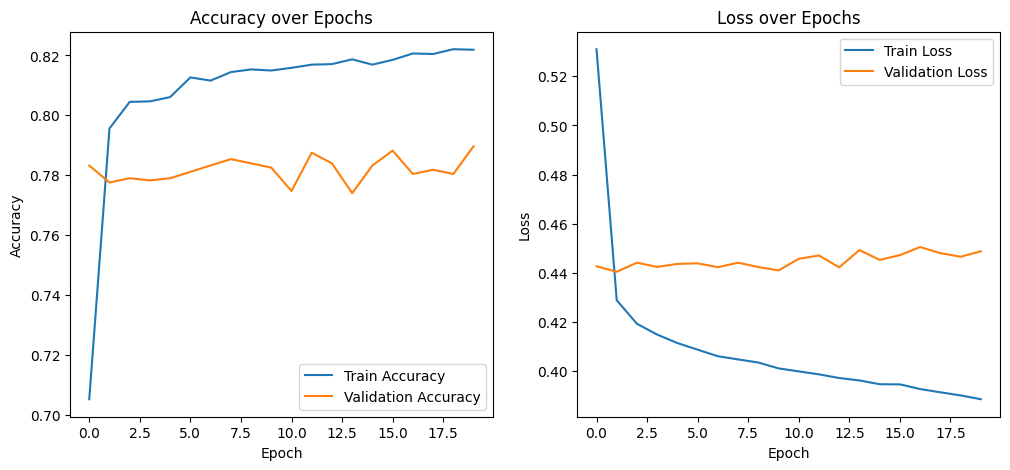

In [ ]:
import matplotlib.pyplot as plt

# 1️⃣ Accuracy plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 2️⃣ Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels (0/1)
y_pred = (y_pred_prob > 0.5).astype(int)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


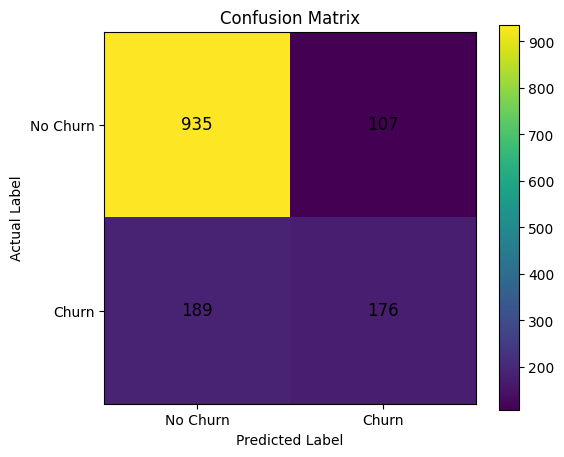

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0,1], ['No Churn', 'Churn'])
plt.yticks([0,1], ['No Churn', 'Churn'])

# Add values inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.colorbar()
plt.show()


In [ ]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)


Precision: 0.6219081272084805
Recall: 0.4821917808219178


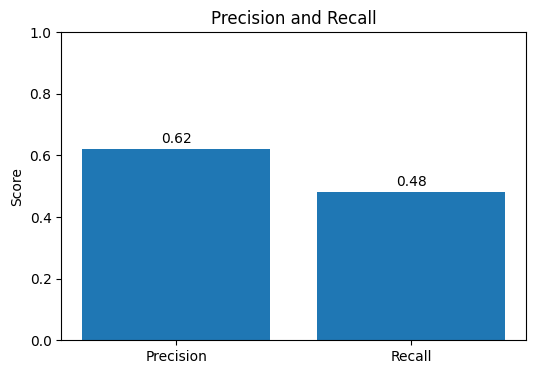

In [ ]:
metrics = ['Precision', 'Recall']
values = [precision, recall]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Precision and Recall")
plt.ylabel("Score")
plt.ylim(0,1)

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Example new customer as a dictionary
new_customer_dict = {
    'Gender': 0,
    'Senior_Citizen': 0,
    'Partner': 1,
    'Dependents': 0,
    'tenure': 12,
    'Phone_Service': 1,
    'Multiple_Lines': 0,
    'Internet_Service': 0,
    'Online_Security': 2,
    'Online_Backup': 0,
    'Device_Protection': 1,
    'Tech_Support': 0,
    'Streaming_TV': 0,
    'Streaming_Movies': 1,
    'Contract': 0,
    'Paperless_Billing': 1,
    'Payment_Method': 2,
    'Monthly_Charges': 50.0,
    'Total_Charges': 500.0
}

# Convert to DataFrame
new_customer_df = pd.DataFrame([new_customer_dict])

# Scale features using the same scaler
new_customer_scaled = scaler.transform(new_customer_df)

# Predict churn
churn_prob = model.predict(new_customer_scaled)[0][0]
churn_label = int(churn_prob > 0.5)

print(f"Churn Probability: {churn_prob:.2f}")
print(f"Churn Prediction: {churn_label} ({'Yes' if churn_label==1 else 'No'})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Churn Probability: 0.24
Churn Prediction: 0 (No)
